In [23]:
import ROOT
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

In [36]:
# Open the ROOT file
# file = ROOT.TFile("higgsCombineTest.MultiDimFit.mH125.root")
# file = ROOT.TFile("higgsCombine.kbkc.MultiDimFit.mH120.root")
# # Access the 'limit' TTree
# tree = file.Get("limit")

tree = ROOT.TChain("limit")
tree.Add("higgsCombine.2024.hbb_hcc.POINTS.9000.9999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.hbb_hcc.POINTS.8000.8999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.hbb_hcc.POINTS.7000.7999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.hbb_hcc.POINTS.6000.6999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.hbb_hcc.POINTS.5000.5999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.hbb_hcc.POINTS.4000.4999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.hbb_hcc.POINTS.3000.3999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.hbb_hcc.POINTS.4000.4999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.hbb_hcc.POINTS.1000.1999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.hbb_hcc.POINTS.0.999.MultiDimFit.mH125.root")

# Prepare lists to store the data
r_ZHbb = []
r_ZHcc = []
deltaNLL = []

# Loop over the entries in the tree and extract the data
for entry in tree:
    r_ZHbb.append(entry.r_VHbb)
    r_ZHcc.append(entry.r_VHcc)

    # r_ZHbb.append(entry.kappa_b)
    # r_ZHcc.append(entry.kappa_c)
    deltaNLL.append(2 * entry.deltaNLL)  # Multiply by 2 for -2Δln(L)

# Close the file
# file.Close()

Best-fit r_ZHbb: 1.0000004768371582
Best-fit r_ZHcc: 0.9999958872795105
Minimum -2Δln(L): 0.0
Plot saved as 2d_likelihood_scan_prl.pdf


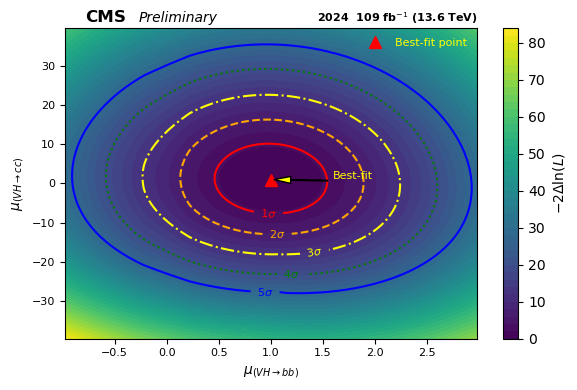

In [37]:
# Convert lists to numpy arrays for plotting
r_ZHbb = np.array(r_ZHbb)
r_ZHcc = np.array(r_ZHcc)
deltaNLL = np.array(deltaNLL)

# Find the best-fit point
min_index = np.argmin(deltaNLL)
best_r_ZHbb = r_ZHbb[min_index]
best_r_ZHcc = r_ZHcc[min_index]
min_deltaNLL = deltaNLL[min_index]

print(f"Best-fit r_ZHbb: {best_r_ZHbb}")
print(f"Best-fit r_ZHcc: {best_r_ZHcc}")
print(f"Minimum -2Δln(L): {min_deltaNLL}")

# Define confidence level thresholds for 1σ, 2σ, etc.
confidence_levels = [2.30, 6.17, 11.83, 19.31, 27.63]

# Create the contour plot
plt.figure(figsize=(6,4))  # Compact PRL-style dimensions
contour = plt.tricontourf(r_ZHbb, r_ZHcc, deltaNLL, levels=50, cmap='viridis')

# Add a colorbar
cbar = plt.colorbar(contour)
cbar.set_label(r'$-2\Delta\ln(L)$', fontsize=10)

# Overlay confidence level contours
contour_lines = plt.tricontour(
    r_ZHbb, r_ZHcc, deltaNLL,
    levels=[min_deltaNLL + cl for cl in confidence_levels],
    colors=['red', 'orange', 'yellow', 'green', 'blue'],
    linestyles=['-', '--', '-.', ':', '-']
)

# Add confidence level labels
fmt = {min_deltaNLL + cl: f'{sigma}$\sigma$' for cl, sigma in zip(confidence_levels, range(1, 6))}
plt.clabel(contour_lines, fmt=fmt, inline=True, fontsize=8)

# Mark the best-fit point
plt.plot(best_r_ZHbb, best_r_ZHcc, 'r^', label='Best-fit point', markersize=8)
plt.annotate(
    'Best-fit', xy=(best_r_ZHbb, best_r_ZHcc), xytext=(best_r_ZHbb + 0.6, best_r_ZHcc + 0.2),
    arrowprops=dict(facecolor='yellow', shrink=0.05, width=0.5, headwidth=5),
    fontsize=8, color='yellow'  # Set the text color here
)

# PRL-style labels and text
plt.xlabel(r'$\mu_{(VH\to bb)}$', fontsize=10)
plt.ylabel(r'$\mu_{(VH\to cc)}$', fontsize=10)
plt.tick_params(axis='both', which='major', labelsize=8)
plt.grid(visible=False)

# Add CMS text
plt.text(0.05, 1.02, "CMS", fontsize=12, fontweight='bold', transform=plt.gca().transAxes)
plt.text(0.18, 1.02, "Preliminary", fontsize=10, style='italic', transform=plt.gca().transAxes)
plt.text(1.0, 1.02, r"2024  109 fb$^{-1}$ (13.6 TeV)", fontsize=8, fontweight='bold', ha='right', transform=plt.gca().transAxes)

# Add legend
# Create the legend
legend = plt.legend(fontsize=8, loc='upper right', frameon=False)

# Change the text color in the legend
for text in legend.get_texts():
    text.set_color('yellow')  # Set your desired color
    
# plt.xlim(0.0, 2.5)
# plt.ylim(-50, 50)

# Save and show the plot
plt.tight_layout()
output_file = "2d_likelihood_scan_prl.pdf"
plt.savefig(output_file)
print(f"Plot saved as {output_file}")
plt.show()


In [31]:
# Open the ROOT file
# file = ROOT.TFile("higgsCombineTest.MultiDimFit.mH125.root")
# file = ROOT.TFile("higgsCombine.kbkc.MultiDimFit.mH120.root")
# # Access the 'limit' TTree
# tree = file.Get("limit")

tree = ROOT.TChain("limit")
tree.Add("higgsCombine.2024.kb_kc.POINTS.0.999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.kb_kc.POINTS.1000.1999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.kb_kc.POINTS.2000.2999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.kb_kc.POINTS.3000.3999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.kb_kc.POINTS.4000.4999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.kb_kc.POINTS.5000.5999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.kb_kc.POINTS.6000.6999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.kb_kc.POINTS.7000.7999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.kb_kc.POINTS.8000.8999.MultiDimFit.mH125.root")
tree.Add("higgsCombine.2024.kb_kc.POINTS.9000.9999.MultiDimFit.mH125.root")

# Prepare lists to store the data
kappa_b = []
kappa_c = []
deltaNLL = []

# Loop over the entries in the tree and extract the data
for entry in tree:
    kappa_b.append(entry.kappa_b)
    kappa_c.append(entry.kappa_c)
    deltaNLL.append(2 * entry.deltaNLL)  # Multiply by 2 for -2Δln(L)

# Close the file
# file.Close()

Best-fit kappa_b: 1.0
Best-fit kappa_c: 1.0
Minimum -2Δln(L): 0.0
Plot saved as 2d_likelihood_kappa_scan_prl.pdf


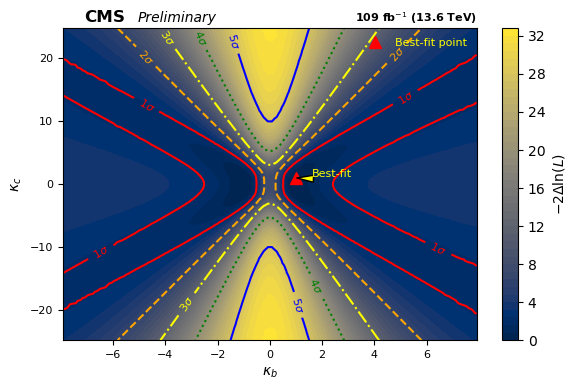

In [33]:
# Convert lists to numpy arrays for plotting
kappa_b = np.array(kappa_b)
kappa_c = np.array(kappa_c)
deltaNLL = np.array(deltaNLL)

# Find the best-fit point
min_index = np.argmin(deltaNLL)
best_kappa_b = kappa_b[min_index]
best_kappa_c = kappa_c[min_index]
min_deltaNLL = deltaNLL[min_index]

print(f"Best-fit kappa_b: {best_kappa_b}")
print(f"Best-fit kappa_c: {best_kappa_c}")
print(f"Minimum -2Δln(L): {min_deltaNLL}")

# Define confidence level thresholds for 1σ, 2σ, etc.
confidence_levels = [2.30, 6.17, 11.83, 19.31, 27.63]

# Create the contour plot
plt.figure(figsize=(6,4))  # Compact PRL-style dimensions
contour = plt.tricontourf(kappa_b, kappa_c, deltaNLL, levels=50, cmap='cividis')

# Add a colorbar
cbar = plt.colorbar(contour)
cbar.set_label(r'$-2\Delta\ln(L)$', fontsize=10)

# Overlay confidence level contours
contour_lines = plt.tricontour(
    kappa_b, kappa_c, deltaNLL,
    levels=[min_deltaNLL + cl for cl in confidence_levels],
    colors=['red', 'orange', 'yellow', 'green', 'blue'],
    linestyles=['-', '--', '-.', ':', '-']
)

# Add confidence level labels
fmt = {min_deltaNLL + cl: f'{sigma}$\sigma$' for cl, sigma in zip(confidence_levels, range(1, 6))}
plt.clabel(contour_lines, fmt=fmt, inline=True, fontsize=8)

# Mark the best-fit point
plt.plot(best_kappa_b, best_kappa_c, 'r^', label='Best-fit point', markersize=8)
plt.annotate(
    'Best-fit', xy=(best_kappa_b, best_kappa_c), xytext=(best_kappa_b + 0.6, best_kappa_c + 0.2),
    arrowprops=dict(facecolor='yellow', shrink=0.05, width=0.5, headwidth=5),
    fontsize=8, color='yellow'  # Set the text color here
)

# PRL-style labels and text
plt.xlabel(r'$\kappa_{b}$', fontsize=10)
plt.ylabel(r'$\kappa_{c}$', fontsize=10)
plt.tick_params(axis='both', which='major', labelsize=8)
plt.grid(visible=False)

# Add CMS text
plt.text(0.05, 1.02, "CMS", fontsize=12, fontweight='bold', transform=plt.gca().transAxes)
plt.text(0.18, 1.02, "Preliminary", fontsize=10, style='italic', transform=plt.gca().transAxes)
plt.text(1.0, 1.02, r"109 fb$^{-1}$ (13.6 TeV)", fontsize=8, fontweight='bold', ha='right', transform=plt.gca().transAxes)

# Add legend
# Create the legend
legend = plt.legend(fontsize=8, loc='upper right', frameon=False)

# Change the text color in the legend
for text in legend.get_texts():
    text.set_color('yellow')  # Set your desired color

# Save and show the plot
plt.tight_layout()
output_file = "2d_likelihood_kappa_scan_prl.pdf"
plt.savefig(output_file)
print(f"Plot saved as {output_file}")
plt.show()
